# twixtools: Recon code

In [1]:
%matplotlib inline
import twixtools
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import torch
import json
from mirtorch_pkg import NuSense_om
from torchkbnufft import calc_density_compensation_function
import Nufftbindings.nufftbindings.kbnufft as kbnufft

main_dir = '/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/MRSI_trajs/data/4Riccardo'
file_name = 'meas_MID00205_FID11344_ad_edMrsi_waterRef_20260521_0535.dat'
dcfnet_path = f'/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/trained_models/dcfnet_512_unet_trained_with_E.pt'
pathTrjRef = "kspace_res50_bw2000Hz_ptls80.mat"
saving_folder = '/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/MRSI_trajs/rosette/reconstructions'
os.makedirs(saving_folder, exist_ok=True)

folder_modules= os.path.abspath('/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit') 
if folder_modules not in sys.path:
    sys.path.append(folder_modules)

from utils_3 import ImageRecon
from params import *
from models import UNet1D

## `read_twix`: Direct access to the raw data

`read_twix` provides low-level access to the Siemens MRI raw data, on a block-by-block ("mdb") level.

    Parameters
    ----------
    infile : filename or measurement id of .dat file
    include_scans: list of scan numbers or None, optional
        By default, all scans in a multi-raid file are parsed.
    parse_prot : bool, optional
        By default, the protocol information is parsed.
        (this is also highly recommended)
    parse_data: bool, optional
        Set to False to parse only protocol information.
    parse_geometry: bool, optional
        Set to False to skip creation of transformation matrix from data
        coordinates to physical coordinates.
    verbose: bool, optional
        Switch progress and other messages on or off.
    keep_acqend : bool, optional
        By default, acqend blocks are not included in the mdb list.
        This block is helpful for twix writing, but unnecessary otherwise.
    keep_syncdata : bool, optional
        By default, syncdata blocks are included in the mdb list.
        These blocks may include physio. (PMU) or trajectory information.

    Returns
    -------
    out: list of twix scan(s)
        The twix scans themselves consist of a dict with these elements:
            - hdr: dict of parsed ascconv and XProtocol header information
            - hdr_str: header bytearray (used by write_twix)
            - mdb: list of measurement data blocks -- here is the MRI data
              use `help(twixtools.mdb.Mdb)` for more information
            - geometry: dict containing geometry information about the scan
              use `help(twixtools.geometry)` for more information

In [2]:
# parse the twix file
twix = twixtools.read_twix(os.path.join(main_dir, file_name))

# twix is a list of measurements:
print('\nnumber of separate scans (multi-raid):', len(twix))

Software version: VD/VE (!?)

Scan  0


100%|██████████| 32.3M/32.3M [00:00<00:00, 1.42GB/s]


Scan  1


100%|██████████| 641M/641M [00:00<00:00, 1.50GB/s]


number of separate scans (multi-raid): 2


In [3]:
# sort all 'imaging' mdbs into a k-space array
image_mdbs = [mdb for mdb in twix[-1]['mdb'] if mdb.is_image_scan()]
print(f"Number of petals: {len(image_mdbs)}") 
print(f"Shape of each petal: {image_mdbs[0].data.shape}") 

Number of petals: 80
Shape of each petal: (32, 32704)


## Correct shape for the k-space input

In [4]:
N_PETALS = 80
N_COILS = 32
N_POINTS_PER_PETAL = 100
N_REPEATS = 325

data_raw = np.array([mdb.data for mdb in image_mdbs])
print(f"Raw stacked shape: {data_raw.shape}") 
# Output: (80, 32, 32704)

# 42 extra points at the beginning are not valid
data_valid = data_raw[:, :, 42:]
print(f"Shape after discarding initial 42 points: {data_valid.shape}")

# We discard last points to get 32500 (100 x 325) valid points per petal
data_valid = data_valid[:, :, :32500]
print(f"Final shape: {data_valid.shape}")

data = data_valid.reshape(N_PETALS, N_COILS, N_REPEATS, N_POINTS_PER_PETAL)
data_t0 = data[:, :, 0, :]  # (petals, coils, points)
data_flat = data_t0.transpose(1, 0, 2).reshape(N_COILS, -1)

print("flat:", data_flat.shape)

Raw stacked shape: (80, 32, 32704)
Shape after discarding initial 42 points: (80, 32, 32662)
Final shape: (80, 32, 32500)
flat: (32, 8000)


## Reconstruction

### Rosette trajectory

(80, 100)
(80, 100)


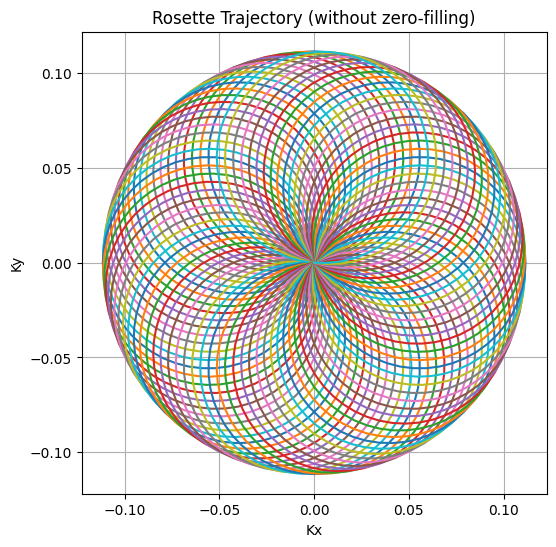

In [5]:
from scipy.io import loadmat
import numpy as np

dataTrjRef = loadmat(pathTrjRef)

Kxy_smp = dataTrjRef["Kxy_smp"]   # shape: (100, 80)
Kmax = float(dataTrjRef["Kmax"].squeeze())

# from (samples, petals) to (petals, samples)
kx = np.real(Kxy_smp).T
ky = np.imag(Kxy_smp).T

kx, ky = kx / Kmax * kmax_traj, ky / Kmax * kmax_traj

print(kx.shape)  # (80, 100)
print(ky.shape)  # (80, 100)

rosette_numpy = np.stack((kx, ky), axis=-1) 
rosette_tensor = torch.tensor(rosette_numpy, dtype=torch.float32)
rosette_tensor = rosette_tensor.reshape(-1, 2)

plt.figure(figsize=[6,6])
for i in range(80):
    plt.plot(kx[i], ky[i])
plt.title('Rosette Trajectory (without zero-filling)')
plt.xlabel('Kx')
plt.ylabel('Ky')
plt.axis('equal')
plt.grid()
plt.show()

### k-space points on rosette

Trajectory samples: (8000, 2)
Data samples per coil: (32, 8000)
Rosette shape: torch.Size([8000, 2])


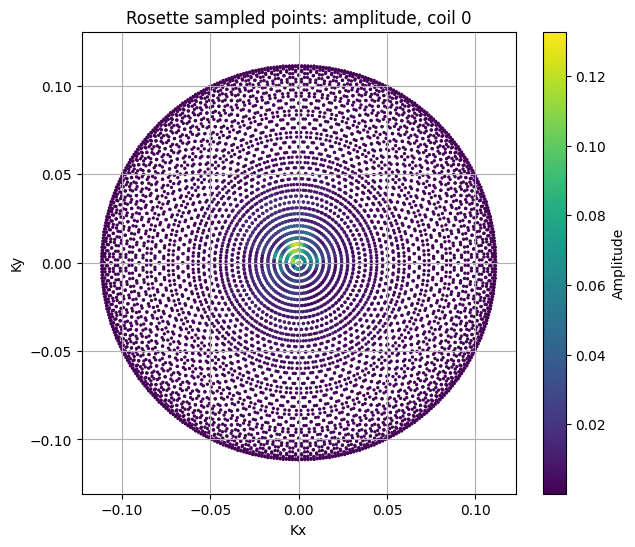

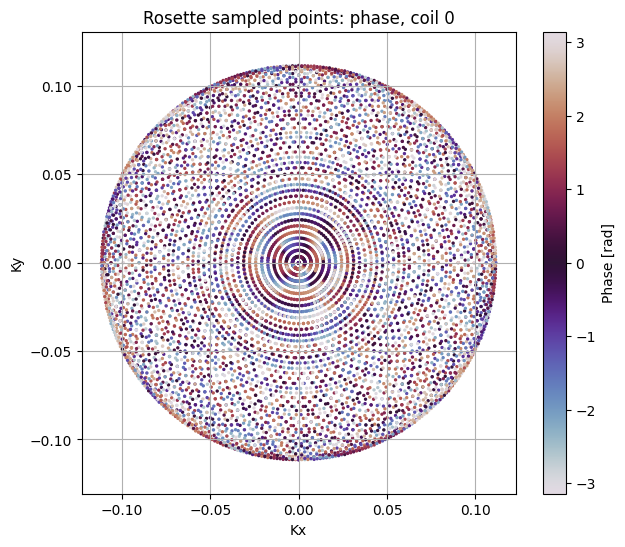

In [6]:
# Trajectory without zero-filling: shape should be (80*100, 2) = (8000, 2)
traj_samples = rosette_numpy.reshape(-1, 2)

print("Trajectory samples:", traj_samples.shape)
print("Data samples per coil:", data_flat.shape)
print(f"Rosette shape: {rosette_tensor.shape}")

# one coil to visualize
coil_idx = 0
s = data_flat[coil_idx, :]   # shape: (8000,)

# Amplitude and phase
A = np.abs(s)
phi = np.angle(s)

kx_flat = traj_samples[:, 0]
ky_flat = traj_samples[:, 1]

# Amplitude plot
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    kx_flat,
    ky_flat,
    c=A,
    s=2,
    cmap='viridis'
)
plt.colorbar(sc, label='Amplitude')
plt.title(f'Rosette sampled points: amplitude, coil {coil_idx}')
plt.xlabel('Kx')
plt.ylabel('Ky')
plt.axis('equal')
plt.grid()
plt.show()

# Phase plot
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    kx_flat,
    ky_flat,
    c=phi,
    s=2,
    cmap='twilight'
)
plt.colorbar(sc, label='Phase [rad]')
plt.title(f'Rosette sampled points: phase, coil {coil_idx}')
plt.xlabel('Kx')
plt.ylabel('Ky')
plt.axis('equal')
plt.grid()
plt.show()

### Image

In [7]:
def reconstruct_rss_dcfnet(data_flat, rosette_tensor, recon):
    images_coils = []

    for i in range(N_COILS):
        sampled_tensor = torch.tensor(data_flat[i], dtype=torch.complex64)

        dummy_data = torch.zeros(2, dtype=torch.complex64)
        sampled_tensor = torch.cat([sampled_tensor, dummy_data], dim=0).to(recon.device)

        img_coil = recon.reconstruct_img_dcfnet(
            rosette_tensor.to(recon.device),
            sampled_tensor
        )
        images_coils.append(img_coil.detach().cpu().numpy())

    images_coils = np.array(images_coils)
    image_rss = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))
    return image_rss

def reconstruct_rss_mirtorch(data_flat, rosette_tensor, recon):
    images_coils = []

    for i in range(N_COILS):
        sampled_tensor = torch.tensor(data_flat[i], dtype=torch.complex64)

        dummy_data = torch.zeros(2, dtype=torch.complex64)
        sampled_tensor = torch.cat([sampled_tensor, dummy_data], dim=0).to(recon.device)

        img_coil = recon.reconstruct_img_mirtorch(
            rosette_tensor.to(recon.device),
            sampled_tensor
        )
        images_coils.append(img_coil.detach().cpu().numpy())

    images_coils = np.array(images_coils)
    image_rss = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))
    return image_rss

### zero-filling

Max k-space value in trajectory: 0.1116
Calculated img_size: 50.0000 1/m
Calculated kmax_img: 0.1116 1/m


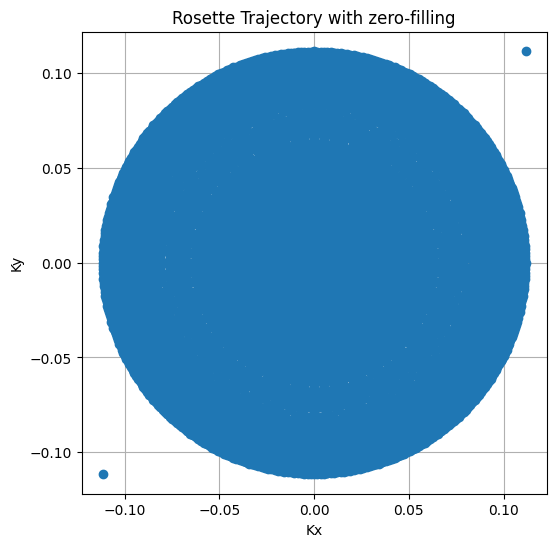

In [ ]:
print(f"Max k-space value in trajectory: {torch.abs(rosette_tensor).max():.4f}")
new_params = params.copy()
new_params["img_size"] = int(np.round(torch.abs(rosette_tensor).max() * 2 * params["FoV"]))
kmax_img = new_params["img_size"] / (2 * params["FoV"])
print(f"Calculated img_size: {new_params['img_size']:.4f}")
print(f"Calculated kmax_img: {kmax_img:.4f} 1/m")

corners = torch.tensor(
    [[kmax_img, kmax_img], [-kmax_img, -kmax_img]],
    device=rosette_tensor.device,
    dtype=rosette_tensor.dtype,
)
rosette_recon = torch.cat([rosette_tensor, corners], dim=0)

recon = ImageRecon(new_params, kmax_img, dcfnet_path)

plt.figure(figsize=[6,6])
plt.plot(rosette_recon[:, 0], rosette_recon[:, 1], 'o')
plt.title('Rosette Trajectory with zero-filling')
plt.xlabel('Kx')
plt.ylabel('Ky')
plt.axis('equal')
plt.grid()
plt.show()  

/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


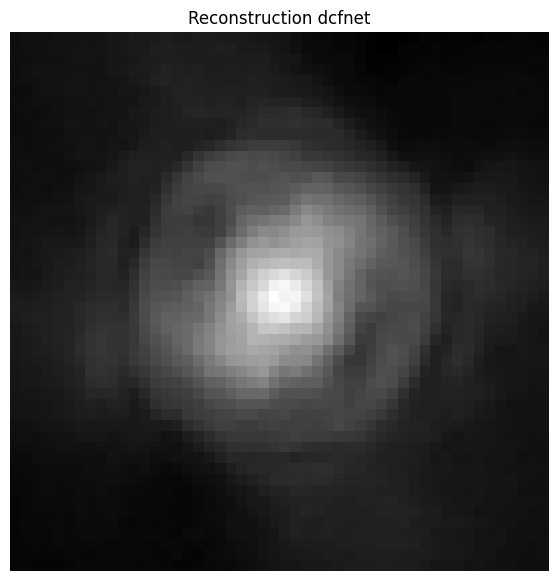

In [9]:
image_scaled = reconstruct_rss_dcfnet(data_flat, rosette_recon, recon)

plt.figure(figsize=(7, 7))
#vmax = np.percentile(image_scaled, 99.5)
#plt.imshow(image_scaled, cmap="gray", origin="lower", vmin=0, vmax=vmax)
plt.imshow(image_scaled, cmap="gray", origin="lower")
plt.title("Reconstruction dcfnet")
plt.axis("off")
plt.savefig(f"{saving_folder}/dcfnet.png", bbox_inches='tight', pad_inches=0)
plt.show()

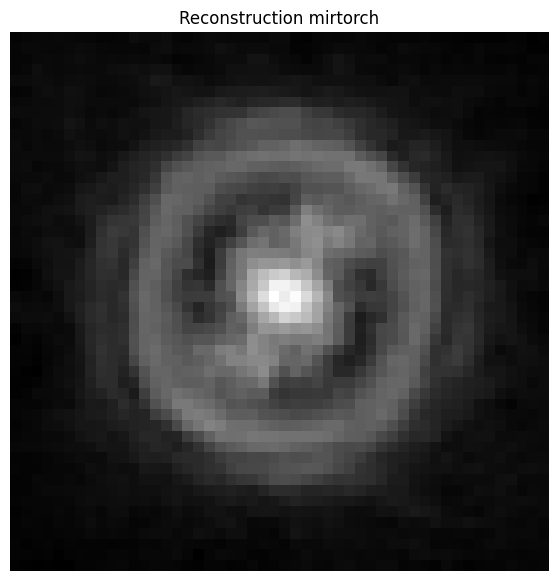

In [10]:
image_scaled = reconstruct_rss_mirtorch(data_flat, rosette_recon, recon)

plt.figure(figsize=(7, 7))
#vmax = np.percentile(image_scaled, 99.5)
#plt.imshow(image_scaled, cmap="gray", origin="lower", vmin=0, vmax=vmax)
plt.imshow(image_scaled, cmap="gray", origin="lower")
plt.title("Reconstruction mirtorch")
plt.axis("off")
plt.savefig(f"{saving_folder}/mirtorch.png", bbox_inches='tight', pad_inches=0)
plt.show()

### dcfnet E

Shape of rosette for DCF computation: torch.Size([8002, 2])
Shape of sampled data for DCF computation: torch.Size([1, 1, 8002])
Shape of DCF before normalization: torch.Size([8002])
shape of w: torch.Size([8002])
shape of ktraj: torch.Size([8002, 2])


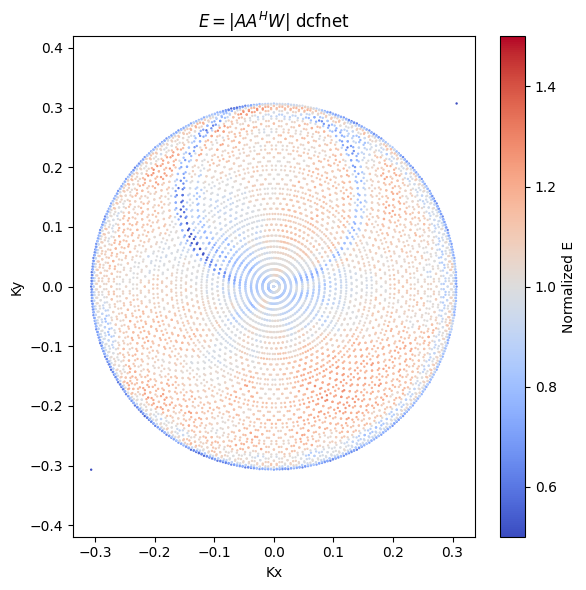

In [11]:
kmax_img = params["img_size"] / (2 * params["FoV"]) # 512x512 image size
recon = ImageRecon(params, kmax_img, dcfnet_path)

dcfdict, kernel_size, features = torch.load(dcfnet_path, map_location=recon.device)
dcfnet = UNet1D(in_channels=2, out_channels=1, features=features, kernel_size=kernel_size)
dcfnet.load_state_dict(dcfdict)
dcfnet.to(recon.device)

# Rosette
rosette = rosette_recon.clone()
rosette = rosette.squeeze() / kmax_img * torch.pi
print(f"Shape of rosette for DCF computation: {rosette.shape}")

# Sampled data for one coil
sampled_tensor = torch.tensor(data_flat[0], dtype=torch.complex64)
dummy_data = torch.zeros(2, dtype=torch.complex64)
sampled_tensor = torch.cat([sampled_tensor, dummy_data], dim=0).to(recon.device)
sampled = sampled_tensor.reshape(1, 1, -1)
print(f"Shape of sampled data for DCF computation: {sampled.shape}")

# kbnufft 
kbnufft.nufft.set_dims(sampled.shape[-1], (params["img_size"], params["img_size"]), device=rosette.device, Nb=1)
kbnufft.nufft.precompute(rosette)

# dcfnet
dcf = dcfnet(rosette[:-2, :].permute(1, 0).unsqueeze(0)).squeeze() + 0j
dcf = torch.cat([dcf, torch.zeros(2, device=dcf.device)], dim=-1)
print(f"Shape of DCF before normalization: {dcf.shape}")

dcf = recon.normalize_dcf(dcf.view(1, 1, -1), rosette, (params["img_size"], params["img_size"]))

# Compute and plot E = |A A^H W| using the same precomputed kbnufft
device = recon.device
w = dcf.to(device).squeeze()          # (N,)
ktraj = rosette.to(device).squeeze()  # (N, 2)

print(f"shape of w: {w.shape}")
print(f"shape of ktraj: {ktraj.shape}")

# Make W complex if needed
if not torch.is_complex(w):
    w = w + 0j

# E = |A A^H W|
# The adjoint maps W to image space: A^H W.
# The forward maps back to k-space: A A^H W.

with torch.no_grad():
    w_kspace = w.view(1, 1, -1)        # (1, 1, N)
    img_density = kbnufft.adjoint(
        ktraj,
        w_kspace.squeeze(0)
    )

    E_complex = kbnufft.forward(
        ktraj,
        img_density
    )

    E = E_complex.abs().squeeze()      # (N,)

# Normalize E so mean(E) = 1
E = E / (E.mean() + 1e-8)

# Plot E over current rosette
kx = ktraj[:, 0].detach().cpu().numpy()
ky = ktraj[:, 1].detach().cpu().numpy()
e_vals = E.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
sc = plt.scatter(
    kx,
    ky,
    c=e_vals,
    cmap="coolwarm",
    s=0.5,
    vmin=0.5,
    vmax=1.5,
)

# note that the colormap is contrained

plt.colorbar(sc, label="Normalized E")
plt.title(r"$E = |A A^H W|$ dcfnet")
plt.xlabel("Kx")
plt.ylabel("Ky")
plt.axis("equal")
plt.tight_layout()
plt.show()

### dcf mirtorch E

Shape of rosette for DCF computation: torch.Size([2, 8002])
Shape of sampled data for DCF computation: torch.Size([1, 1, 8002])
Shape of DCF before normalization: torch.Size([1, 1, 8002])
Shape of DCF before normalization: torch.Size([8002])
shape of w: torch.Size([8002])
shape of ktraj: torch.Size([8002, 2])


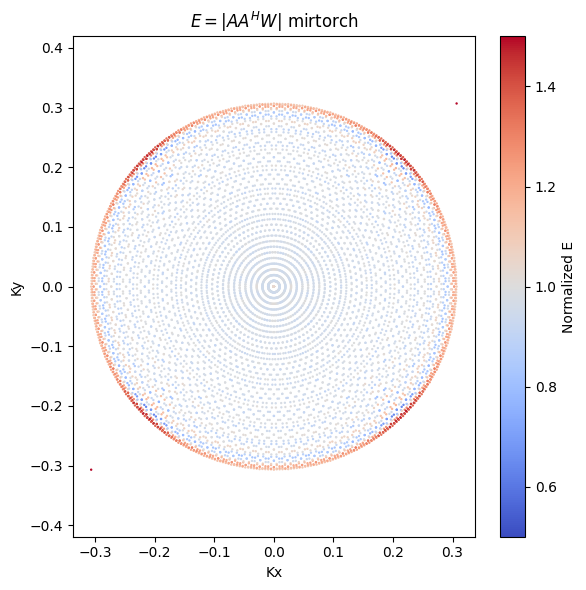

In [12]:
# rosette
rosette = rosette_recon.clone()
rosette = rosette.squeeze().permute(1, 0) / kmax_img * torch.pi
print(f"Shape of rosette for DCF computation: {rosette.shape}")

# sampled
sampled_tensor = torch.tensor(data_flat[0], dtype=torch.complex64)
dummy_data = torch.zeros(2, dtype=torch.complex64)
sampled_tensor = torch.cat([sampled_tensor, dummy_data], dim=0).to(recon.device)
sampled = sampled_tensor.reshape(1, 1, -1)
print(f"Shape of sampled data for DCF computation: {sampled.shape}")

# dcfnet
s0 = torch.ones(1, 1, params["img_size"], params["img_size"], device=sampled.device) + 0j
Nop = NuSense_om(s0, rosette.reshape(1, 2, -1), norm=None)
dcf = calc_density_compensation_function(rosette, (params["img_size"], params["img_size"])) + 0j
dcf = recon.normalize_dcf_mirtorch(dcf.view(1, 1, -1), Nop)
print(f"Shape of DCF before normalization: {dcf.shape}")
dcf = dcf.reshape(-1)
print(f"Shape of DCF before normalization: {dcf.shape}")

# Compute and plot E = |A A^H W| using the same precomputed kbnufft
device = recon.device
w = dcf.to(device).squeeze()         
ktraj = rosette.to(device).squeeze()  
ktraj = ktraj.T # needed for mirtorch

print(f"shape of w: {w.shape}")
print(f"shape of ktraj: {ktraj.shape}")

# Make W complex if needed
if not torch.is_complex(w):
    w = w + 0j

# E = |A A^H W|
# The adjoint maps W to image space: A^H W.
# The forward maps back to k-space: A A^H W.

with torch.no_grad():
    w_kspace = w.view(1, 1, -1)        # (1, 1, N)
    img_density = kbnufft.adjoint(
        ktraj,
        w_kspace.squeeze(0)
    )

    E_complex = kbnufft.forward(
        ktraj,
        img_density
    )

    E = E_complex.abs().squeeze()      # (N,)

# Normalize E so mean(E) = 1
E = E / (E.mean() + 1e-8)

# Plot E over current rosette
kx = ktraj[:, 0].detach().cpu().numpy()
ky = ktraj[:, 1].detach().cpu().numpy()
e_vals = E.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
sc = plt.scatter(
    kx,
    ky,
    c=e_vals,
    cmap="coolwarm",
    s=0.5,
    vmin=0.5,
    vmax=1.5,
)

plt.colorbar(sc, label="Normalized E")
plt.title(r"$E = |A A^H W|$ mirtorch")
plt.xlabel("Kx")
plt.ylabel("Ky")
plt.axis("equal")
plt.tight_layout()
plt.show()